# Part B — 04 Model Evaluation

This notebook evaluates the classification models in greater detail.

The models are evaluated using patents granted in 2023.

The 2024 patent data remains untouched and is reserved for final model
testing after model selection and hyperparameter tuning.

Evaluation focuses on:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Confusion Matrix
- ROC Curve
- Precision-Recall Curve

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

ROOT = Path.cwd().parent

PROCESSED_DIR = ROOT / "Data" / "processed"
TABLES_DIR = ROOT / "Outputs" / "tables"
FIGURES_DIR = ROOT / "Outputs" / "figures"

DATA_PATH = (
    PROCESSED_DIR /
    "01_part_b_target_dataset.parquet"
)

df = pd.read_parquet(DATA_PATH)

print("Rows:", f"{len(df):,}")
print("Columns:", df.shape[1])

Rows: 49,556
Columns: 26


In [2]:
numeric_features = [
    "inventor_count",
    "assignee_count",
    "cpc_count",
    "backward_citation_count",
    "title_word_count",
    "abstract_word_count",
    "claims_text_length",
    "claims_word_count",
    "filing_to_grant_days"
]

categorical_features = [
    "cpc_group",
    "assignee_country"
]

feature_columns = (
    numeric_features +
    categorical_features
)

X = df[feature_columns].copy()
y = df["high_impact"].copy()

In [3]:
train_mask = df["grant_year"].isin([2021, 2022])
validation_mask = df["grant_year"] == 2023

X_train = X.loc[train_mask].copy()
y_train = y.loc[train_mask].copy()

X_val = X.loc[validation_mask].copy()
y_val = y.loc[validation_mask].copy()

print("Training:", X_train.shape)
print("Validation:", X_val.shape)

Training: (26465, 11)
Validation: (17597, 11)


In [4]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [5]:
models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            class_weight="balanced",
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )
}

In [6]:
trained_models = {}
predictions = {}
probabilities = {}

for name, classifier in models.items():

    print(f"Training {name} ...")

    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "classifier",
                classifier
            )
        ]
    )

    pipeline.fit(
        X_train,
        y_train
    )

    trained_models[name] = pipeline

    predictions[name] = pipeline.predict(
        X_val
    )

    probabilities[name] = (
        pipeline.predict_proba(
            X_val
        )[:, 1]
    )

print("\nEvaluation models ready.")

Training Logistic Regression ...
Training Decision Tree ...
Training Random Forest ...

Evaluation models ready.


In [7]:
evaluation_results = []

for name in models.keys():

    pred = predictions[name]
    prob = probabilities[name]

    evaluation_results.append({
        "Model": name,

        "Accuracy":
            accuracy_score(
                y_val,
                pred
            ),

        "Precision":
            precision_score(
                y_val,
                pred
            ),

        "Recall":
            recall_score(
                y_val,
                pred
            ),

        "F1":
            f1_score(
                y_val,
                pred
            ),

        "ROC_AUC":
            roc_auc_score(
                y_val,
                prob
            ),

        "PR_AUC":
            average_precision_score(
                y_val,
                prob
            )
    })

evaluation_df = pd.DataFrame(
    evaluation_results
)

evaluation_df = (
    evaluation_df
    .sort_values(
        "ROC_AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

evaluation_df.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Random Forest,0.725,0.344,0.346,0.345,0.647,0.323
1,Logistic Regression,0.558,0.274,0.673,0.389,0.636,0.305
2,Decision Tree,0.664,0.264,0.339,0.297,0.545,0.228


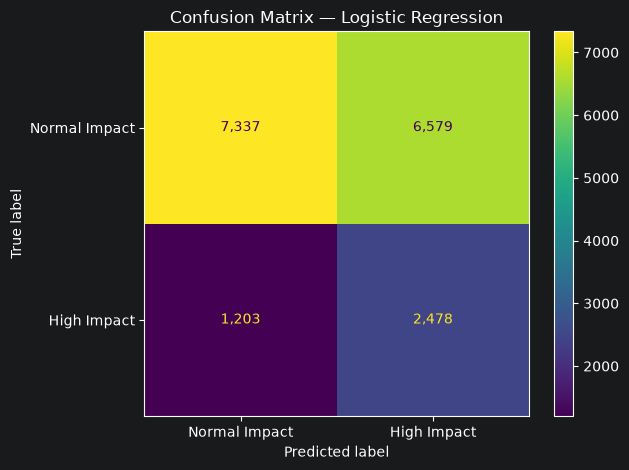

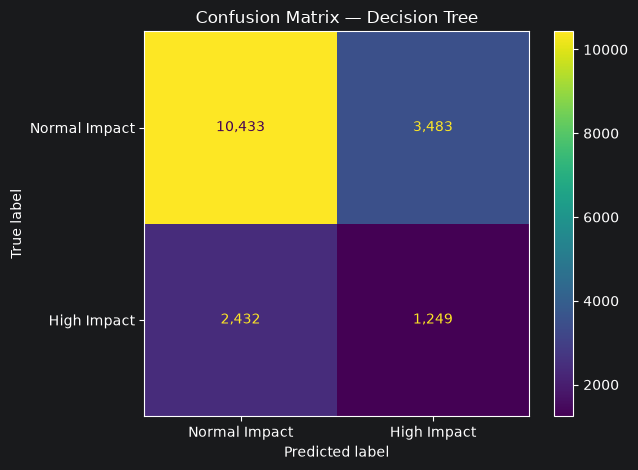

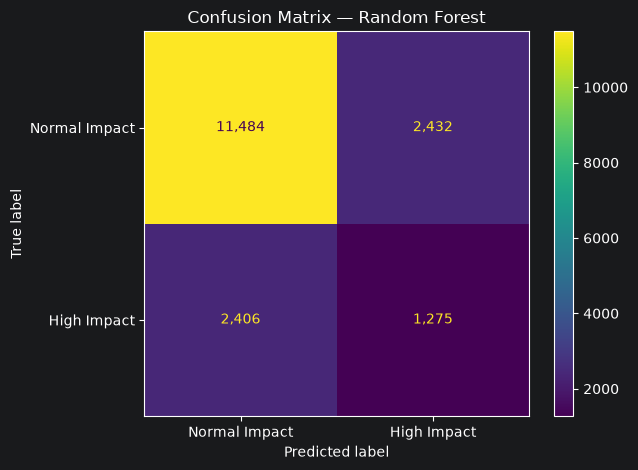

In [8]:
for name in models.keys():

    cm = confusion_matrix(
        y_val,
        predictions[name]
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[
            "Normal Impact",
            "High Impact"
        ]
    )

    disp.plot(
        values_format=","
    )

    plt.title(
        f"Confusion Matrix — {name}"
    )

    plt.tight_layout()
    plt.show()

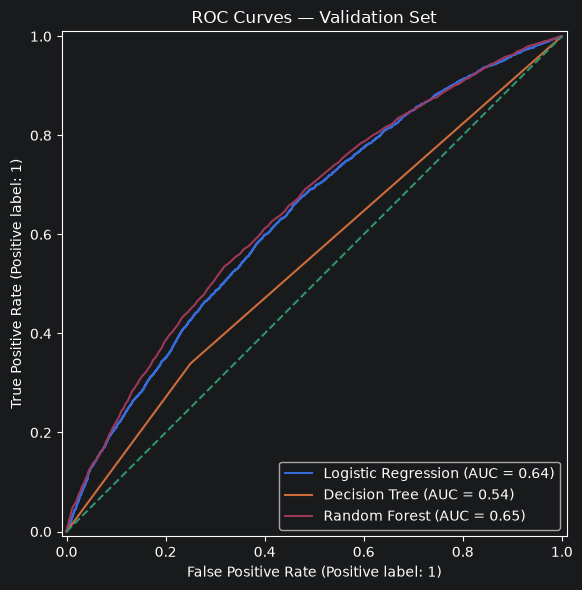

In [9]:
plt.figure(figsize=(8, 6))

ax = plt.gca()

for name in models.keys():

    RocCurveDisplay.from_predictions(
        y_val,
        probabilities[name],
        name=name,
        ax=ax
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title(
    "ROC Curves — Validation Set"
)

plt.tight_layout()
plt.show()

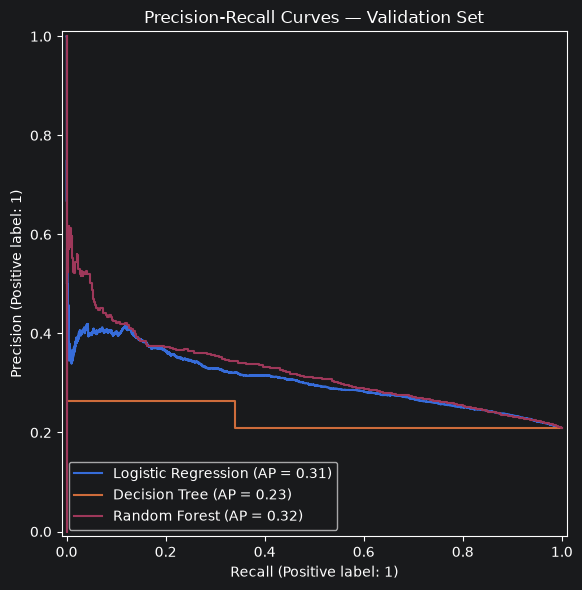

In [10]:
plt.figure(figsize=(8, 6))

ax = plt.gca()

for name in models.keys():

    PrecisionRecallDisplay.from_predictions(
        y_val,
        probabilities[name],
        name=name,
        ax=ax
    )

plt.title(
    "Precision-Recall Curves — Validation Set"
)

plt.tight_layout()
plt.show()

In [11]:
EVALUATION_PATH = (
    TABLES_DIR /
    "part_b_detailed_model_evaluation.csv"
)

evaluation_df.to_csv(
    EVALUATION_PATH,
    index=False
)

print("Saved:", EVALUATION_PATH)

Saved: /Users/janakdobariya/Bramha/NLP_Engineering/BA/ai_patent_business_analytics/Outputs/tables/part_b_detailed_model_evaluation.csv
